### View FCI level 2 cloud mask in grib (.bin) format
https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-clm-and-cla-data-guide#ID-Using-FCI-L2-products

In [1]:
import glob
from datetime import datetime, timedelta
from satpy.scene import Scene

data_dir = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/unzipped/2-CLM/"
sensing_start_time = datetime(2025, 2, 2, 0, 0)
sensing_end_time = sensing_start_time + timedelta(minutes=10)

product = "CLM"
format = "bin"  # "nc" for netCDF or "bin" for GRIB2
filenames = glob.glob(f"{data_dir}W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-{product}-*{sensing_start_time.strftime('%Y%m%d%H%M%S')}_{sensing_end_time.strftime('%Y%m%d%H%M%S')}*.{format}")

# Initialize Scene object
reader = "fci_l2_nc" if format == "nc" else "fci_l2_grib"
scn = Scene(filenames=filenames, reader=reader)
print("Available datasets:", scn.available_dataset_names()) # Prints list of available datasets
print("Available composites:", scn.available_composite_names()) # Prints list of potentially available composites

dataset = "cloud_state" if format == "nc" else "cloud_mask"  # Dataset to load
# note: the data inside the FCI files is stored upside down. 
# The upper_right_corner='NE' argument flips it in upright position.
scn.load([dataset], upper_right_corner='NE')

# Extract dataset from Scene object
cloud_state = scn[dataset]  # daskified xarra.DataArray with the FCI CLM cloud_state dataset

# Extract area definition with information about projection, dataset shape and area extent
adef = cloud_state.attrs['area']  # Pyresample AreaDefinition object
print(adef)

# Compute the center longitudes and latitudes of the cloud_state dataset grid
lons, lats = adef.get_lonlats()  # 2D arrays with pixel centre longitude and latitude

# Retrieve data values of a dataset in form of a common numpy array. This will trigger computations and
# load data into memory
data = cloud_state.values

Available datasets: ['cloud_mask']
Available composites: []
Area ID: msg_fci_fdss_2km
Description: MSG FCI Full Disk Scanning Service area definition with 2 km resolution
Projection: {'a': '6378140', 'h': '35785830.098', 'lon_0': '0', 'no_defs': 'None', 'proj': 'geos', 'rf': '298.252981061492', 'type': 'crs', 'units': 'm', 'x_0': '0', 'y_0': '0'}
Number of columns: 5568
Number of rows: 5568
Area extent: (np.float64(-5568000.0), np.float64(-5568000.0), np.float64(5568000.0), np.float64(5568000.0))


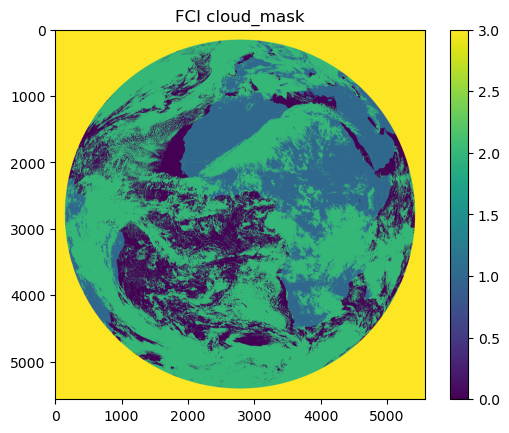

In [4]:
import matplotlib.pyplot as plt

plt.imshow(data)
plt.title(f"FCI {dataset}")
plt.colorbar()
plt.show()